In [10]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [160]:
deg = 3      #polynomial degree
N = deg+1        #number of cells
maxiter = 1

f={0:lambda x,y: 1., 1:lambda x,y: 1.} #rhs
nu = {0:1000.}                          #diffusion with a possible second subdomain
dir_data = {0:0}                       #zero dirichlet
prim = {'v':0, 'e':0}                  #vertex value primal/ edge averages primal
Prec = "1"                             #"1": no preconditioner, "selection":selection scaling

plot=not False

In [161]:
knots = (bspline.make_knots(deg,0,1,N),bspline.make_knots(deg,0,1,N))
M = topology.MultiPatch([(knots,geometry.quarter_annulus())])
M.h_refine();

#M.set_domain_id({1:(0,)})

IMap = ieti.IetiMapper(M, dir_data)

setting up constraints took 0.01261281967163086 seconds.


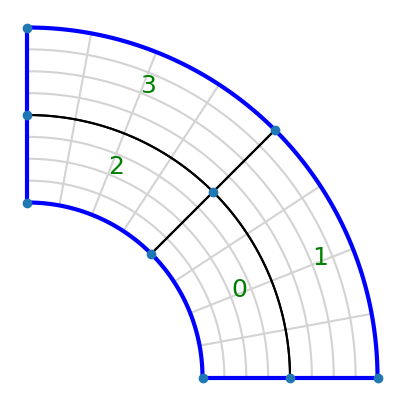

In [162]:
if plot:
    M.plotmesh(figsize=(5,5),color={1:'orange',0:'white'}, knots=1, bwidth=3, nodes=1, bcolor={0:'blue'}, patch_idx=1)
    plt.axis('off');
    plt.axis('scaled');
    plt.show()

In [163]:
A, RHS = IMap.assemble(a=nu,f=f, M=None)
N = [A.shape[0] for A in A]
B, eliminated_constraints = IMap.ConstraintMatrices(redundant=False)
        
SD = ieti.ScaledDirichletPreconditioner(A, B, IMap)
    
Prim = csc_matrix((IMap.nLocDofs,0))
        #print(IMap.nodes_as_primals())
if prim['v']:
    Prim = scipy.sparse.hstack([Prim, IMap.nodes_as_primals()])
if prim['e']:
    Prim = scipy.sparse.hstack([Prim, IMap.interface_averages_as_primals()])
        #print(Prim)
if Prim.shape[1]==0:
    I = ieti.IetiSystem(A, B, RHS, N)
    F, b = I.SchurComplement(), I.RHSforSchurComplement()
else:
    primal = ieti.PrimalSystem(Prim)
    A, B, RHS, C = primal.incorporate_PrimalConstraints(A, B, RHS, IMap)
    loc_solver = primal.compute_PrimalBasis(A, B, RHS, C)
        
    A.append(primal.A_prim), B.append(primal.B_prim), RHS.append(primal.RHS_prim)
    loc_solver.append(solvers.make_solver(primal.A_prim, spd=True, symm=True)), N.append(primal.A_prim.shape[0])
        
    I = ieti.IetiSystem(A, B, RHS, N, loc_solver)
    F, b = I.SchurComplement(), I.RHSforSchurComplement()
    
if Prec=='selection':
    SD.setupSelectionScaling()
    lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=SD.prec(), output=1, rtol=1e-6, atol=1e-12)
elif Prec=='deluxe':
    prec=ieti.EdgePreconditioner(IMap, SD.SchurMatrices(), SD.B ,C)
    #print(Prec@np.eye(Prec.shape[0]))
    lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=prec, output=1, rtol=1e-6, atol=1e-12)
elif Prec=='coefficient':
    SD.setupCoefficientScaling(nu)
    lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=SD.prec(), output=1, rtol=1e-6, atol=1e-12)
else:
    print("no preconditioner.")
    lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=1, output=1, rtol=1e-6, atol=1e-12)
            
#u = I.constructSolutionFromLagrangeMultipliers(lam)
#if Prim.shape[1]!=0:
#    u = primal.distributePrimalSolution(u)
#u = IMap.completeDirichlet(u)

#u = np.concatenate(u)

no preconditioner.
pcg with preconditioned condition number κ ~ 5.214 stopped after 12 iterations with relres 6.55e-07 after 0.0028 seconds.


In [18]:
IMap.B.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(16, 64))

In [6]:
np.linalg.cond(F@np.eye(F.shape[0]))

np.float64(1.87268688201985e+16)

In [7]:
#plot primal constraints of patch p
p=0
print(C[p].shape)
C[p].toarray()

(3, 9)


array([[0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 1.     ],
       [0.     , 0.     , 0.     , 0.     , 0.     , 0.     , 0.33333, 0.33333, 0.16667],
       [0.     , 0.     , 0.326  , 0.     , 0.     , 0.34403, 0.     , 0.     , 0.17524]])

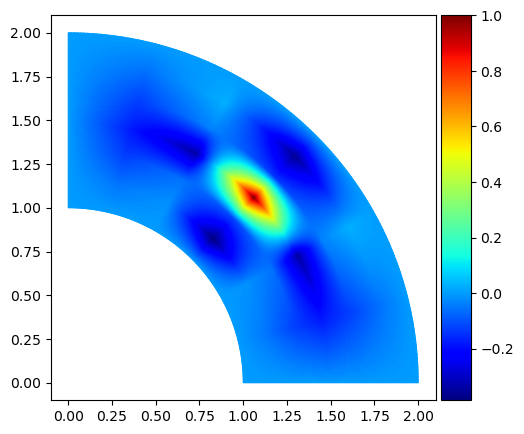

In [8]:
#Plot i-th primal basis
i=0
Psi = [primal.Psi[p][:,i].toarray().ravel() for p in range (IMap.nPatches)] #take the primal basis from patch p and the i-th column
IMap.plot(np.concatenate(IMap.completeDirichlet(Psi)));                     #complete with dirichlet values and plot